In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.family'] = 'sans-serif'

In [4]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
print(df.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


<h4> rows where penguins are missing in all four measurements </h4> 

In [6]:
measurements = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

missing_measurements = df[df[measurements].isnull().all(axis=1)]
missing_measurements

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


<h4> rows where sex is missing </h4>

In [20]:
# Filter rows where sex is missing
missing_sex = df[df["sex"].isnull()]
missing_sex

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


<h4> dropping rows where all four measurements are absent because these rows won't tells anything about the species of penguins</h4>

In [11]:
df_clean = df.dropna(subset=["bill_length_mm"]).copy()
df_clean.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
dtype: int64

<h4>Rows missing only the sex variable were retained in the dataset rather than dropped. Because these rows contain complete physical measurements and species classifications, keeping them preserves full statistical power for species-level distributions and comparisons where biological sex is not a factor. </h4>

In [12]:
df_clean["sex"] = df_clean["sex"].fillna("UNKNOWN")

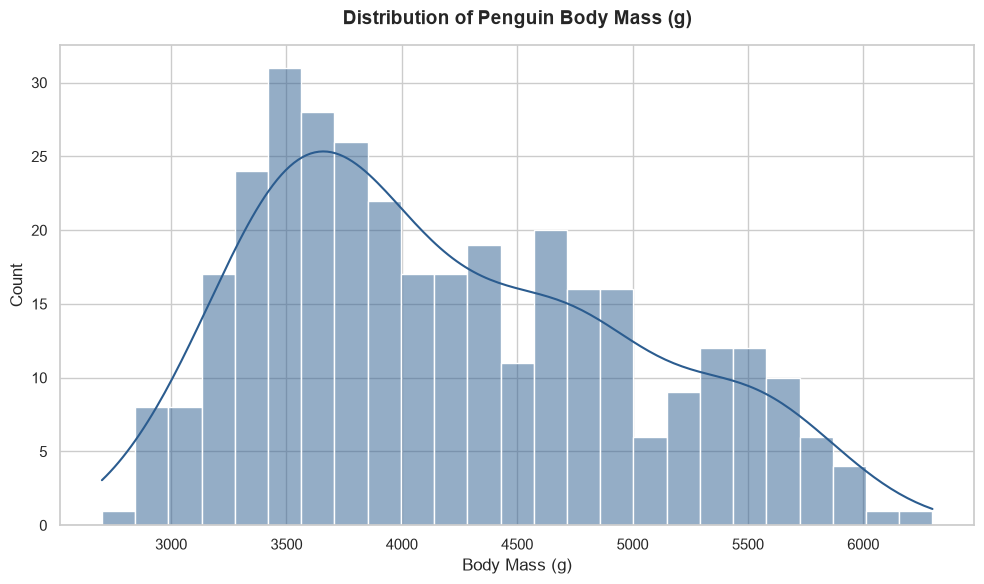

In [24]:
# 2. Set plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create histogram with Kernel Density Estimate (KDE)
# Option A: Overall distribution
sns.histplot(
    data=df,
    x="body_mass_g",
    kde=True,
    bins=25,
    color="#2b5c8f",
    edgecolor="white",
)

# Customize title and labels
plt.title("Distribution of Penguin Body Mass (g)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Body Mass (g)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

<h4> In the distribution of the body mass of penguins three humps are present when that same distribution is re-drawn and split by species it was found
that one hump in above distribution is of Adélie and Chinstrap , second and third hump is of Gentoo which tells female and male gento has different range of body mass</h4>

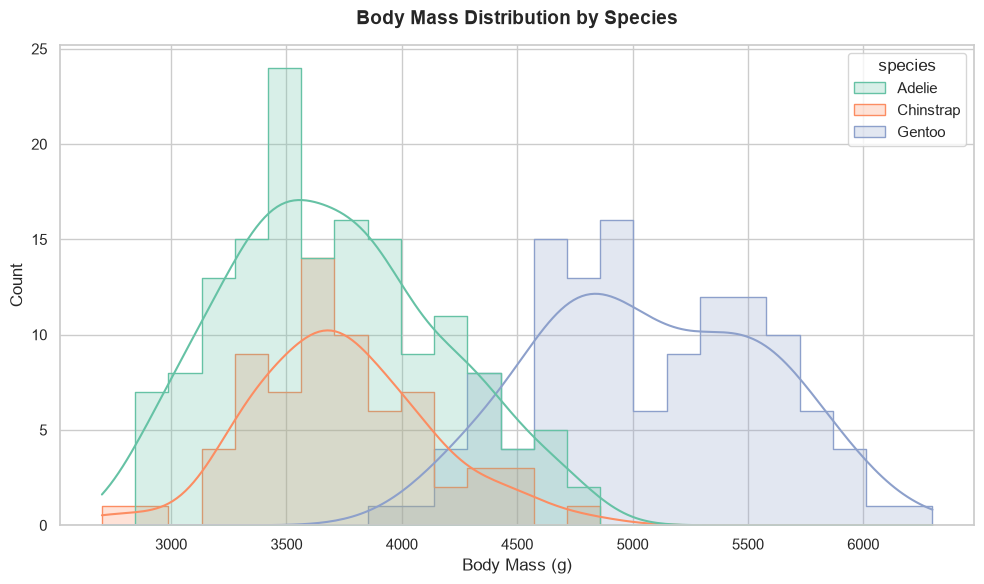

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="body_mass_g",
    hue="species",
    kde=True,
    bins=25,
    palette="Set2",
    element="step",
)

plt.title("Body Mass Distribution by Species", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Body Mass (g)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

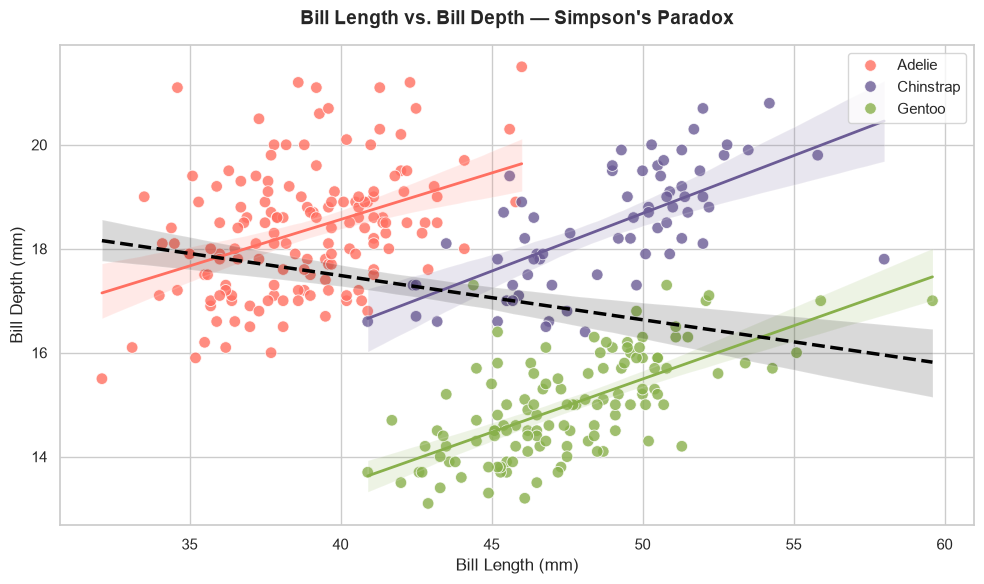

In [27]:
# 2. Set theme and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Define palette for species
palette = {"Adelie": "#FF6F61", "Chinstrap": "#6B5B95", "Gentoo": "#88B04B"}

# 3. Scatter plot grouped by species
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette=palette,
    s=70,
    alpha=0.8,
)

# 4. Add per-species positive regression lines
for species, color in palette.items():
    subset = df[df["species"] == species]
    sns.regplot(
        data=subset,
        x="bill_length_mm",
        y="bill_depth_mm",
        scatter=False,
        color=color,
        ax=plt.gca(),
        line_kws={"linewidth": 2},
    )

# 5. Add overall dataset negative regression line
sns.regplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    scatter=False,
    color="black",
    ax=plt.gca(),
    line_kws={
        "linestyle": "--",
        "linewidth": 2.5,
        "label": "Overall Trend (Negative)",
    },
)

# Customize title and axis labels
plt.title(
    "Bill Length vs. Bill Depth — Simpson's Paradox",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Bill Length (mm)", fontsize=12)
plt.ylabel("Bill Depth (mm)", fontsize=12)

# Set legend position
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, loc="upper right")

plt.tight_layout()
plt.show()

<h4> a statistical relationship that appears in aggregate data can reverse or disappear when the data is split into distinct subgroups (in this case, species). </h4>

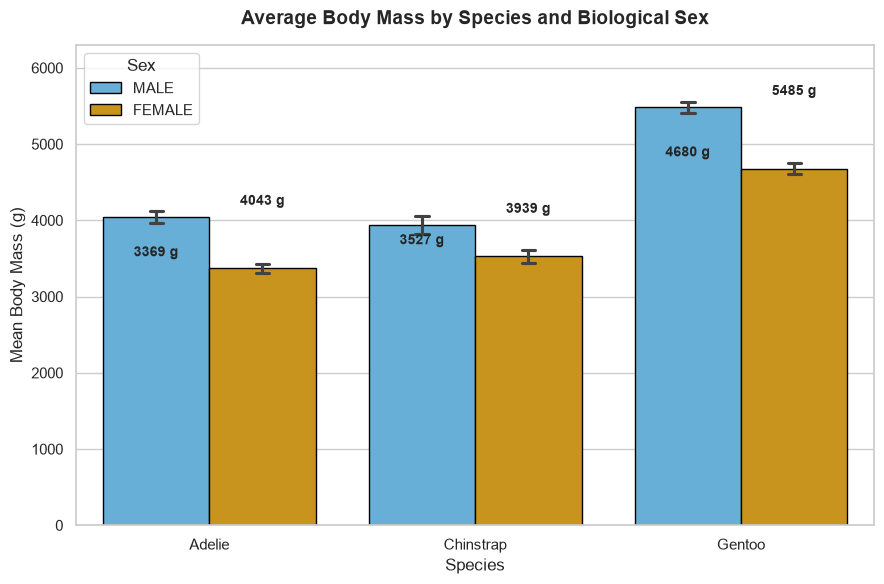

In [30]:
# 2. Set styling
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 3. Create grouped bar chart for mean body mass
ax = sns.barplot(
    data=df,
    x="species",
    y="body_mass_g",
    hue="sex",
    palette={"FEMALE": "#E69F00", "MALE": "#56B4E9"},
    errorbar="ci",
    capsize=0.1,
    edgecolor="black",
    linewidth=1,
)

# 4. Annotate mean values on top of each bar
means = df.groupby(["species", "sex"])["body_mass_g"].mean().unstack()
for i, species in enumerate(["Adelie", "Chinstrap", "Gentoo"]):
    for j, sex in enumerate(["FEMALE", "MALE"]):
        val = means.loc[species, sex]
        x_pos = i - 0.2 + (j * 0.4)
        ax.text(
            x_pos,
            val + 120,
            f"{val:.0f} g",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

# Titles and Labels
plt.title(
    "Average Body Mass by Species and Biological Sex",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Species", fontsize=12)
plt.ylabel("Mean Body Mass (g)", fontsize=12)
plt.ylim(0, 6300)
plt.legend(title="Sex", loc="upper left")

plt.tight_layout()
plt.show()